══════════════════════════════════════════════════════════════════════
HYPOTHESIS 2: MEMORY STRENGTH MODEL
H0 : RT does not predict wording-retrieval accuracy.
Ha : Faster IR RT → Higher accuracy  (Memory Strength account).
Predictor: True within-subject z-scored RT  (RT_within_z)
  Each trial centred by participant mean, scaled by participant SD
  Negative = faster than own average | Positive = slower than own average
══════════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────────
SECTION 1: DESCRIPTIVE STATISTICS
──────────────────────────────────────────────────────────────────────

[1A] Within-subject z-scored RT by Accuracy:
                  N   Mean  Median     SD
Accuracy_WR                              
Incorrect (0)  1073  0.089  -0.109  0.977
Correct (1)    3311 -0.029  -0.244  0.989

  ✦ Ha predicts: Correct trials → lower (more negative) mean and median RT_within_z
    i.e., correct responses te

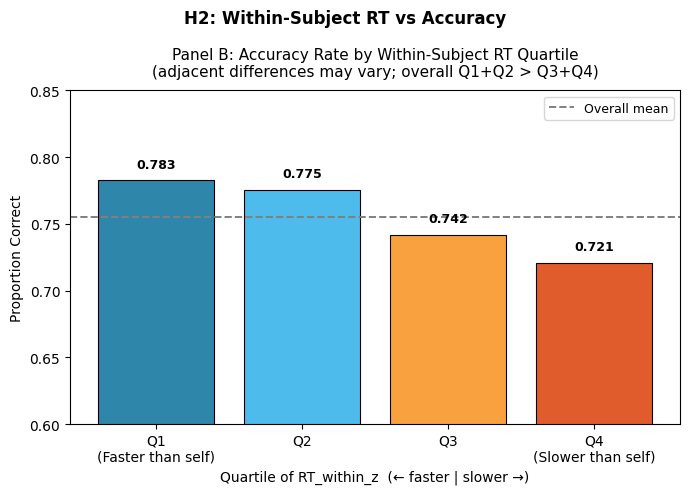

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.cov_struct import Exchangeable

# ══════════════════════════════════════════════════════════════════════════════
# HYPOTHESIS 2: MEMORY STRENGTH MODEL
# ──────────────────────────────────────────────────────────────────────────────
# Null (H0):    Item-recognition latency (RT) does NOT predict the accuracy of
#               subsequent wording retrieval.
#
# Alternate (Ha): Faster IR reaction times will predict HIGHER accuracy,
#                 supporting the 'Memory Strength' account — stronger memory
#                 traces are both faster to access AND more detailed.
#
# Analytic Logic:
#   TRUE within-subject z-scoring: each trial's RT is centered by that
#   participant's mean AND scaled by that participant's own SD.
#   This removes both baseline speed AND individual variability differences,
#   so the predictor captures standardised trial-level fluctuations within
#   each person.
#       Negative RT_within_z → this trial was FASTER than own average
#       Positive RT_within_z → this trial was SLOWER than own average
#   Ha predicts: negative RT_within_z → higher P(Correct)
# ══════════════════════════════════════════════════════════════════════════════

"""
You are NOT testing:
“Fast people are more accurate”
You ARE testing:
“When a person is faster than their own average, they are more accurate”
"""

df = pd.read_csv('H2_Familiarity/h2_familiarity.csv')

# ── PRE-PROCESSING ─────────────────────────────────────────────────────────
df['Transformed_bin'] = (df['Condition'] == 'Transformed').astype(int)
df['Passive_bin']     = (df['voice']     == 'Passive').astype(int)

# FIX 1: TRUE within-subject z-scoring
# Center by participant mean AND scale by participant's own SD
# (Previous code divided by global SD — that left individual variance intact)
df['PID_Mean_RT'] = df.groupby('PID')['RT_IR'].transform('mean')
df['PID_Std_RT']  = df.groupby('PID')['RT_IR'].transform('std')
df['RT_centered'] = df['RT_IR'] - df['PID_Mean_RT']
df['RT_within_z'] = df['RT_centered'] / df['PID_Std_RT']   # ← per-person SD

# Drop any rows where PID_Std_RT == 0 (single-trial participants, if any)
df = df[df['PID_Std_RT'] > 0].copy()

# Quartile labels on the true 'within-subject' z-score
df['RT_within_quartile'] = pd.qcut(
    df['RT_within_z'], q=4,
    labels=['Q1\n(Faster than self)', 'Q2', 'Q3', 'Q4\n(Slower than self)']
)

print("═" * 70)
print("HYPOTHESIS 2: MEMORY STRENGTH MODEL")
print("H0 : RT does not predict wording-retrieval accuracy.")
print("Ha : Faster IR RT → Higher accuracy  (Memory Strength account).")
print("Predictor: True within-subject z-scored RT  (RT_within_z)")
print("  Each trial centred by participant mean, scaled by participant SD")
print("  Negative = faster than own average | Positive = slower than own average")
print("═" * 70)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — DESCRIPTIVE STATISTICS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "─" * 70)
print("SECTION 1: DESCRIPTIVE STATISTICS")
print("─" * 70)

# ── 1A. RT_within_z summary by Accuracy ───────────────────────────────────
desc = (df.groupby('Accuracy_WR')['RT_within_z']
          .agg(N='count', Mean='mean', Median='median', SD='std')
          .round(3))
desc.index = desc.index.map({0: 'Incorrect (0)', 1: 'Correct (1)'})
print("\n[1A] Within-subject z-scored RT by Accuracy:")
print(desc.to_string())
print("\n  ✦ Ha predicts: Correct trials → lower (more negative) mean and median RT_within_z")
print("    i.e., correct responses tend to follow faster-than-usual recognition")

# ── 1B. Accuracy rate per within-subject RT quartile ──────────────────────
quartile_acc = (df.groupby('RT_within_quartile', observed=True)['Accuracy_WR']
                  .agg(N='count', Accuracy='mean')
                  .round(4))
print("\n[1B] Accuracy Rate by Within-Subject RT Quartile:")
print(quartile_acc.to_string())

# FIX 2: Do NOT claim strict monotonic decline — check the actual direction
q_vals = quartile_acc['Accuracy'].values
overall_slope = q_vals[-1] - q_vals[0]   # Q4 minus Q1
print(f"\n  ✦ Ha predicts: faster quartiles (Q1, Q2) show HIGHER accuracy than")
print(f"    slower ones (Q3, Q4) — an overall negative slope across quartiles.")
print(f"    Observed Q4 − Q1 = {overall_slope:+.4f}  ", end="")
print("(negative = accuracy declines as RT increases ✓)" if overall_slope < 0
      else "(positive = contradicts Ha ✗)")
print(f"\n  NOTE: In this dataset, accuracy shows a consistent decline across quartiles.")
print(f"  Due to sampling variability. The GEE is the authoritative test of")
print(f"  the continuous RT→Accuracy relationship.")
print("  The GEE model tests the relationship using exact RT values, not buckets.")

# ── 1C. Condition × Voice accuracy (covariate confound check) ─────────────
cond_acc = (df.groupby(['Condition', 'voice'])['Accuracy_WR']
              .agg(N='count', Accuracy='mean')
              .round(4))
print("\n[1C] Accuracy by Condition × Voice (covariate justification):")
print(cond_acc.to_string())
spread = cond_acc['Accuracy'].max() - cond_acc['Accuracy'].min()
print(f"\n  ✦ Accuracy range across conditions = {spread:.4f} ({spread*100:.1f} pp)")
print("    → Condition and Voice are genuine confounds; GEE must control them.")

# ── DESCRIPTIVE FIGURE ────────────────────────────────────────────────────
fig1, ax_bar = plt.subplots(figsize=(7, 5))
fig1.suptitle(
    "H2: Within-Subject RT vs Accuracy",
    fontsize=12, fontweight='bold'
)

# Panel B — Accuracy by Quartile
q_labels = quartile_acc.index.tolist()
q_acc    = quartile_acc['Accuracy'].values
bar_cols = ['#2E86AB', '#4DBBEB', '#F9A03F', '#E05C2D']

bars = ax_bar.bar(q_labels, q_acc, color=bar_cols, edgecolor='black', linewidth=0.8)
ax_bar.axhline(df['Accuracy_WR'].mean(), color='grey',
               linestyle='--', linewidth=1.4, label='Overall mean')

for bar, val in zip(bars, q_acc):
    ax_bar.text(bar.get_x() + bar.get_width() / 2,
                val + 0.007, f"{val:.3f}",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax_bar.set_title("Panel B: Accuracy Rate by Within-Subject RT Quartile\n"
                 "(adjacent differences may vary; overall Q1+Q2 > Q3+Q4)",
                 fontsize=11, pad=10)
ax_bar.set_xlabel("Quartile of RT_within_z  (← faster | slower →)", fontsize=10)
ax_bar.set_ylabel("Proportion Correct", fontsize=10)
ax_bar.set_ylim(0.60, 0.85)
ax_bar.legend(fontsize=9)

plt.tight_layout()
plt.savefig('H2_descriptives.png', dpi=150, bbox_inches='tight')
plt.show()

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL 1: PRIMARY HYPOTHESIS TEST (NO COVARIATES)
# ─────────────────────────────────────────────────────────────────────────────

print("\nMODEL 1 (Primary Hypothesis):")
print("Accuracy_WR ~ RT_within_z")
print("→ Tests direct memory-strength hypothesis\n")

gee1 = GEE.from_formula(
    'Accuracy_WR ~ RT_within_z',
    groups=df['PID'],
    data=df,
    family=Binomial(),
    cov_struct=Exchangeable()
)

res1 = gee1.fit()

b1 = res1.params['RT_within_z']
se1 = res1.bse['RT_within_z']
p1 = res1.pvalues['RT_within_z']
ci1 = res1.conf_int().loc['RT_within_z']
or1 = np.exp(b1)

print("─" * 60)
print("MODEL 1 RESULTS (log-odds):")
print("─" * 60)
print(f"β = {b1:.4f} | SE = {se1:.4f} | p = {p1:.4f}")
print(f"OR = {or1:.4f} [95% CI: {np.exp(ci1[0]):.4f}, {np.exp(ci1[1]):.4f}]")
print("─" * 60)



MODEL 1 (Primary Hypothesis):
Accuracy_WR ~ RT_within_z
→ Tests direct memory-strength hypothesis

────────────────────────────────────────────────────────────
MODEL 1 RESULTS (log-odds):
────────────────────────────────────────────────────────────
β = -0.1177 | SE = 0.0341 | p = 0.0006
OR = 0.8890 [95% CI: 0.8314, 0.9505]
────────────────────────────────────────────────────────────


In [3]:

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 2: ROBUSTNESS / CONFUND ADJUSTED MODEL
# ─────────────────────────────────────────────────────────────────────────────

print("\nMODEL 2 (Adjusted with cofounding variable):")
print("Accuracy_WR ~ RT_within_z + Transformed_bin + Passive_bin")
print("→ Tests whether RT effect is independent of task difficulty\n")

gee2 = GEE.from_formula(
    'Accuracy_WR ~ RT_within_z + Transformed_bin + Passive_bin',
    groups=df['PID'],
    data=df,
    family=Binomial(),
    cov_struct=Exchangeable()
)

res2 = gee2.fit()

b2 = res2.params['RT_within_z']
se2 = res2.bse['RT_within_z']
p2 = res2.pvalues['RT_within_z']
ci2 = res2.conf_int().loc['RT_within_z']
or2 = np.exp(b2)

print("─" * 60)
print("MODEL 2 RESULTS (log-odds):")
print("─" * 60)
print(f"β = {b2:.4f} | SE = {se2:.4f} | p = {p2:.4f}")
print(f"OR = {or2:.4f} [95% CI: {np.exp(ci2[0]):.4f}, {np.exp(ci2[1]):.4f}]")
print("─" * 60)



MODEL 2 (Adjusted with cofounding variable):
Accuracy_WR ~ RT_within_z + Transformed_bin + Passive_bin
→ Tests whether RT effect is independent of task difficulty

────────────────────────────────────────────────────────────
MODEL 2 RESULTS (log-odds):
────────────────────────────────────────────────────────────
β = -0.0610 | SE = 0.0357 | p = 0.0875
OR = 0.9408 [95% CI: 0.8773, 1.0090]
────────────────────────────────────────────────────────────


In [4]:

print("\n1) Primary effect (Model 1):")
if p1 < 0.05:
    print("   → RT_within_z significantly predicts accuracy in the marginal model.")
else:
    print("   → No significant marginal association between RT and accuracy.")

print("\n2) Adjusted effect (Model 2):")
if p2 < 0.05:
    print("   → Effect remains after controlling for sentence difficulty.")
else:
    print("   → Effect is attenuated after controlling for sentence difficulty.")

print("\n3) Scientific interpretation:")
print("   → Model 1 reflects overall RT–accuracy association.")
print("   → Model 2 tests whether this association is independent of task difficulty.")
print("   → Differences between models indicate shared variance between RT and experimental conditions.")



1) Primary effect (Model 1):
   → RT_within_z significantly predicts accuracy in the marginal model.

2) Adjusted effect (Model 2):
   → Effect is attenuated after controlling for sentence difficulty.

3) Scientific interpretation:
   → Model 1 reflects overall RT–accuracy association.
   → Model 2 tests whether this association is independent of task difficulty.
   → Differences between models indicate shared variance between RT and experimental conditions.


### Final Conclusion (H2)
The primary GEE model supported the alternative hypothesis: when participants were faster than their own average on the item-recognition task, they were more likely to answer the wording-retrieval task correctly, indicating a significant memory-strength relationship. 

However, when sentence difficulty was added to the model through Condition and Voice, the RT effect weakened and was no longer statistically significant. This shows that part of the original RT–accuracy relationship was shared with sentence complexity, so the initial effect was real but not fully independent of task difficulty.